# Static Malware Detection Using Explainable Machine Learning
### MSc Applied Computing — Cybersecurity Project

**Primary Dataset:** EMBER 2018 (Windows PE static features)  
**Primary Model:** LightGBM  
**Baselines:** Random Forest, Logistic Regression  
**Explainability:** SHAP (global + local)

---
**Notebook Structure:**
1. Environment Setup & Imports
2. Data Loading & Inspection
3. Exploratory Data Analysis (EDA)
4. Preprocessing & Class Imbalance Strategies
5. Model Training (LightGBM, Random Forest, Logistic Regression)
6. Evaluation (F1, AUC-ROC, Precision, Recall)
7. SHAP Explainability — Global & Local
8. Cybersecurity Insight Analysis
9. Summary & Conclusions

## 1. Environment Setup & Imports

In [7]:
!pip install git+https://github.com/elastic/ember.git
!pip install -q lightgbm shap imbalanced-learn scikit-learn matplotlib seaborn pandas numpy joblib lief


  Cloning https://github.com/elastic/ember.git to /private/var/folders/tk/phz_1l5d5yx_93mnp2hhywkr0000gn/T/pip-req-build-wjydp_8l
  Running command git clone --filter=blob:none --quiet https://github.com/elastic/ember.git /private/var/folders/tk/phz_1l5d5yx_93mnp2hhywkr0000gn/T/pip-req-build-wjydp_8l
  Resolved https://github.com/elastic/ember.git to commit d97a0b523de02f3fe5ea6089d080abacab6ee931
  Preparing metadata (setup.py) ... done


In [8]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import shap

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import lightgbm as lgb

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Plot style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})
PALETTE = {'benign': '#4C9BE8', 'malicious': '#E84C4C'}

print(f'LightGBM  : {lgb.__version__}')
print(f'SHAP      : {shap.__version__}')
print(f'NumPy     : {np.__version__}')
print(f'Pandas    : {pd.__version__}')

LightGBM  : 4.6.0
SHAP      : 0.51.0
NumPy     : 2.1.3
Pandas    : 2.2.3


## 2. Data Loading & Inspection

EMBER 2018 provides pre-extracted features from Windows PE files.  
Download with: `ember.download_data(data_url, data_dir)` or place the raw files in `EMBER_DATA_DIR`.

> **Predefined split:** We use EMBER's official train/test split to ensure comparability with prior work (Anderson & Roth, 2018).

In [ ]:
import ember

# ── Set this to your local EMBER data directory ───────────────────────────────

EMBER_DATA_DIR = './data/ember2018/'   # <-- change if needed
#ember.create_vectorized_features(EMBER_DATA_DIR)



# Create vectorised feature files if needed
if not os.path.exists(os.path.join(EMBER_DATA_DIR, 'X_train.dat')):
    print('Vectorising features (first-time setup) ...')
    ember.create_vectorized_features(EMBER_DATA_DIR)

# Load official train / test split
print('Loading feature arrays ...')
X_train_full, y_train_full, X_test, y_test = ember.read_vectorized_features(EMBER_DATA_DIR)

# EMBER uses -1 for unlabelled samples — remove them from training
train_mask = y_train_full != -1
X_train_full = X_train_full[train_mask]
y_train_full = y_train_full[train_mask]

test_mask = y_test != -1
X_test = X_test[test_mask]
y_test = y_test[test_mask]

print(f'Training samples : {X_train_full.shape[0]:,}  |  Features: {X_train_full.shape[1]:,}')
print(f'Test samples     : {X_test.shape[0]:,}')
print(f'Class balance (train) — Benign: {(y_train_full==0).sum():,}  |  Malicious: {(y_train_full==1).sum():,}')

Vectorizing training set


100%|██████████| 800000/800000 [29:26<00:00, 452.92it/s]  


Vectorizing test set


100%|██████████| 200000/200000 [07:20<00:00, 454.33it/s]


Loading feature arrays ...
Training samples : 600,000  |  Features: 2,381
Test samples     : 200,000
Class balance (train) — Benign: 300,000  |  Malicious: 300,000


In [10]:
# ── Carve out a held-out validation set from training data (10%) ──────────────
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.10,
    stratify=y_train_full,
    random_state=RANDOM_STATE
)

print(f'Train : {X_train.shape[0]:,}  |  Val : {X_val.shape[0]:,}  |  Test : {X_test.shape[0]:,}')

Train : 540,000  |  Val : 60,000  |  Test : 200,000


In [ ]:
# ── Load EMBER feature names for interpretability ─────────────────────────────
#feature_names = ember.features.FeatureType().feature_names()
#print(f'Feature names loaded: {len(feature_names)}')
#print('Sample feature names:', feature_names[:10])

AttributeError: 'FeatureType' object has no attribute 'feature_names'

In [15]:
feature_names = [f'feature_{i}' for i in range(X_train.shape[1])]
print(f'Feature names loaded: {len(feature_names)}')

Feature names loaded: 2381


## 3. Exploratory Data Analysis

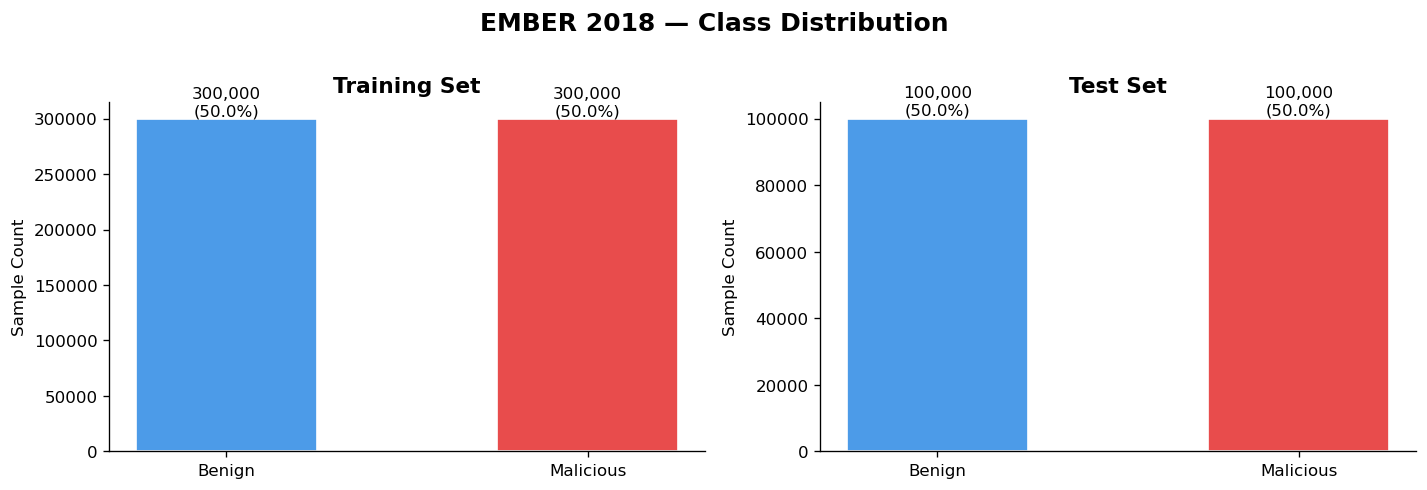

Imbalance ratio (benign:malicious) = 1.00:1


In [16]:
# ── 3.1 Class Distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels = ['Benign', 'Malicious']
train_counts = [(y_train_full == 0).sum(), (y_train_full == 1).sum()]
test_counts  = [(y_test == 0).sum(),       (y_test == 1).sum()]

colors = [PALETTE['benign'], PALETTE['malicious']]

for ax, counts, title in zip(axes, [train_counts, test_counts], ['Training Set', 'Test Set']):
    bars = ax.bar(labels, counts, color=colors, width=0.5, edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_ylabel('Sample Count')
    for bar, count in zip(bars, counts):
        pct = count / sum(counts) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

fig.suptitle('EMBER 2018 — Class Distribution', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_class_distribution.png', bbox_inches='tight')
plt.show()

imbalance_ratio = train_counts[0] / train_counts[1]
print(f'Imbalance ratio (benign:malicious) = {imbalance_ratio:.2f}:1')

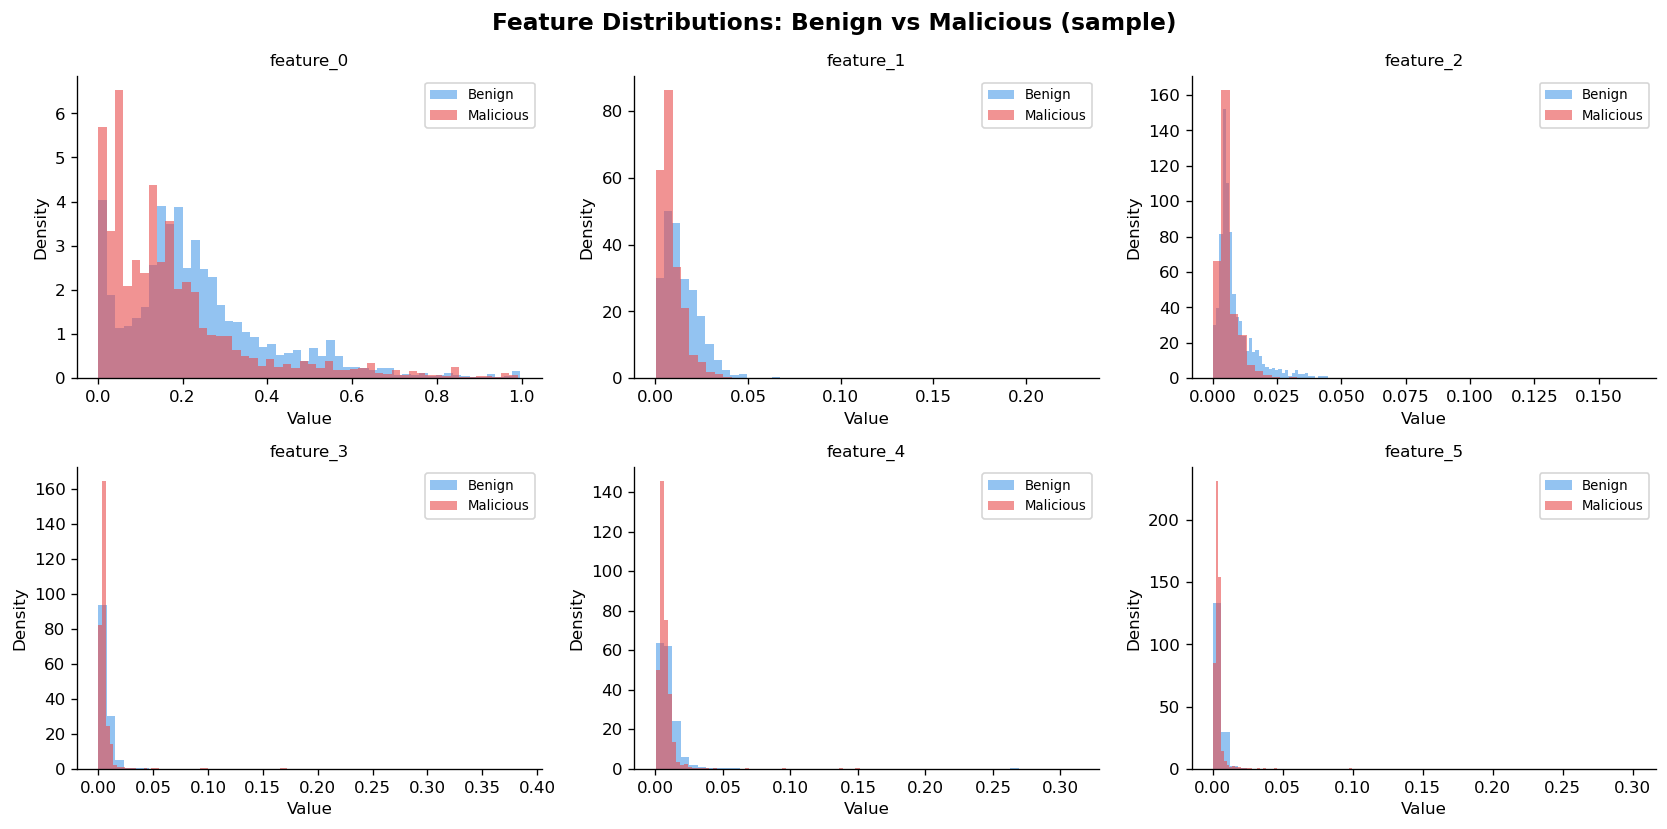

In [17]:
# ── 3.2 Feature Distribution — Top discriminative features ────────────────────
# Convert a subset to DataFrame for plotting
PLOT_FEATURES = 6
sample_idx = np.random.choice(len(X_train_full), size=5000, replace=False)
df_sample = pd.DataFrame(X_train_full[sample_idx, :PLOT_FEATURES],
                         columns=feature_names[:PLOT_FEATURES])
df_sample['label'] = y_train_full[sample_idx].astype(int)
df_sample['Class'] = df_sample['label'].map({0: 'Benign', 1: 'Malicious'})

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, feat in enumerate(feature_names[:PLOT_FEATURES]):
    for cls, color in PALETTE.items():
        subset = df_sample[df_sample['Class'].str.lower() == cls][feat]
        axes[i].hist(subset, bins=50, alpha=0.6, color=color,
                     label=cls.capitalize(), density=True)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

fig.suptitle('Feature Distributions: Benign vs Malicious (sample)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_feature_distributions.png', bbox_inches='tight')
plt.show()

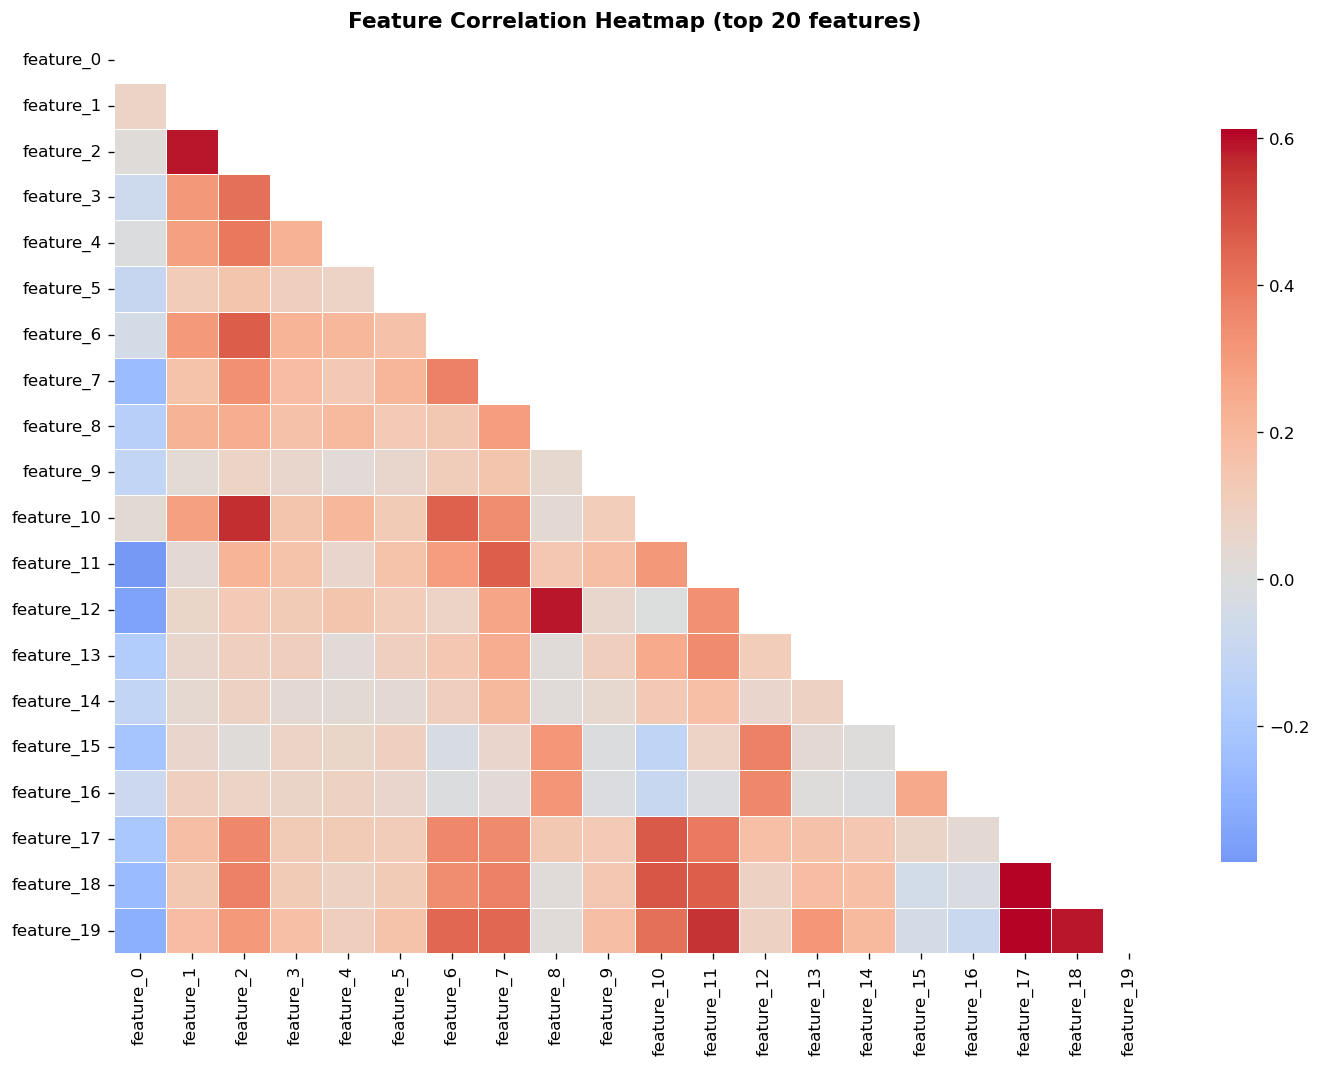

In [18]:
# ── 3.3 Correlation Heatmap (top features) ────────────────────────────────────
TOP_N = 20
df_corr = pd.DataFrame(X_train_full[sample_idx, :TOP_N], columns=feature_names[:TOP_N])
corr_matrix = df_corr.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
            center=0, linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title(f'Feature Correlation Heatmap (top {TOP_N} features)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 4. Preprocessing & Class Imbalance Strategies

We compare three strategies:
- **No resampling** (baseline)
- **Class-weighted loss**
- **SMOTE oversampling**

In [19]:
# ── Compute class weights for weighted models ─────────────────────────────────
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print('Class weights:', class_weight_dict)

# ── SMOTE resampled training data ─────────────────────────────────────────────
# Note: SMOTE is computationally expensive on the full dataset.
# We apply it here; for large runs consider using RandomOverSampler instead.
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f'Original train shape  : {X_train.shape[0]:,}')
print(f'SMOTE resampled shape : {X_train_smote.shape[0]:,}')
print(f'SMOTE class balance   : Benign={( y_train_smote==0).sum():,} | Malicious={(y_train_smote==1).sum():,}')

Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}
Original train shape  : 540,000
SMOTE resampled shape : 540,000
SMOTE class balance   : Benign=270,000 | Malicious=270,000


## 5. Model Training

### 5.1 LightGBM (Primary Model)

In [20]:
# ── LightGBM — no resampling (class_weight handled via scale_pos_weight) ──────
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

lgbm_params = dict(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    scale_pos_weight=pos_weight,   # handles class imbalance
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

lgbm_model = lgb.LGBMClassifier(**lgbm_params)

lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

print(f'Best iteration: {lgbm_model.best_iteration_}')
joblib.dump(lgbm_model, 'lgbm_model.pkl')
print('LightGBM model saved.')

[100]	valid_0's binary_logloss: 0.139947
[200]	valid_0's binary_logloss: 0.0991798
[300]	valid_0's binary_logloss: 0.0835275
[400]	valid_0's binary_logloss: 0.0748467
[500]	valid_0's binary_logloss: 0.0688977
[600]	valid_0's binary_logloss: 0.0645937
[700]	valid_0's binary_logloss: 0.061414
[800]	valid_0's binary_logloss: 0.0586981
[900]	valid_0's binary_logloss: 0.0564151
[1000]	valid_0's binary_logloss: 0.0544779
Best iteration: 1000
LightGBM model saved.


### 5.2 Random Forest (Baseline)

In [22]:
from sklearn.model_selection import train_test_split

# ── Use a stratified subsample for baselines ──────────────────────────────────
# 100k samples is plenty for RF and LR to converge; full dataset is overkill
X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train,
    train_size=100_000,
    stratify=y_train,
    random_state=RANDOM_STATE
)
print(f'Subsample shape: {X_sub.shape}')

Subsample shape: (100000, 2381)


In [24]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_sub, y_sub)
joblib.dump(rf_model, 'rf_model.pkl')
print('Random Forest model saved.')

Random Forest model saved.


### 5.3 Logistic Regression (Baseline)

In [26]:
# LR requires feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_sub)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    solver='saga',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

lr_model.fit(X_train_scaled, y_sub)
joblib.dump(lr_model, 'lr_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print('Logistic Regression model saved.')

Logistic Regression model saved.


## 6. Evaluation

Primary metrics: **F1-score** and **AUC-ROC** (more informative than accuracy under imbalance).  
We also report Precision and Recall to understand the false-negative cost (missed malware).

In [27]:
def evaluate_model(model, X, y, model_name, use_scaled=False, scaler=None):
    """Return a dict of evaluation metrics and print a classification report."""
    X_eval = scaler.transform(X) if use_scaled else X
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]

    metrics = dict(
        model      = model_name,
        accuracy   = (y_pred == y).mean(),
        precision  = precision_score(y, y_pred),
        recall     = recall_score(y, y_pred),
        f1         = f1_score(y, y_pred),
        auc_roc    = roc_auc_score(y, y_prob)
    )

    print(f'\n{'='*55}')
    print(f'  {model_name}')
    print(f'{'='*55}')
    print(classification_report(y, y_pred, target_names=['Benign', 'Malicious']))
    print(f'  AUC-ROC : {metrics["auc_roc"]:.4f}')

    return metrics, y_prob

# Evaluate all models on the held-out TEST set
results = []
roc_data = {}

for model, name, scaled in [
    (lgbm_model, 'LightGBM',            False),
    (rf_model,   'Random Forest',        False),
    (lr_model,   'Logistic Regression',  True),
]:
    metrics, y_prob = evaluate_model(
        model, X_test, y_test, name,
        use_scaled=scaled, scaler=scaler if scaled else None
    )
    results.append(metrics)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr, metrics['auc_roc'])


  LightGBM
              precision    recall  f1-score   support

      Benign       0.97      0.97      0.97    100000
   Malicious       0.97      0.97      0.97    100000

    accuracy                           0.97    200000
   macro avg       0.97      0.97      0.97    200000
weighted avg       0.97      0.97      0.97    200000

  AUC-ROC : 0.9952

  Random Forest
              precision    recall  f1-score   support

      Benign       0.93      0.92      0.92    100000
   Malicious       0.92      0.93      0.93    100000

    accuracy                           0.92    200000
   macro avg       0.93      0.92      0.92    200000
weighted avg       0.93      0.92      0.92    200000

  AUC-ROC : 0.9791

  Logistic Regression
              precision    recall  f1-score   support

      Benign       0.89      0.74      0.81    100000
   Malicious       0.78      0.91      0.84    100000

    accuracy                           0.83    200000
   macro avg       0.84      0.83     

In [28]:
# ── Results summary table ─────────────────────────────────────────────────────
results_df = pd.DataFrame(results).set_index('model')
results_df = results_df[['accuracy', 'precision', 'recall', 'f1', 'auc_roc']]
results_df.columns = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']

print('\n── Test Set Performance Summary ──')
display(results_df.style
    .format('{:.4f}')
    .highlight_max(axis=0, color='#b6d7a8')
    .set_caption('Green = best per column'))


── Test Set Performance Summary ──


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
model,,,,,
LightGBM,0.9714,0.9733,0.9695,0.9714,0.9952
Random Forest,0.9249,0.9170,0.9345,0.9256,0.9791
Logistic Regression,0.8271,0.7803,0.9107,0.8404,0.9273


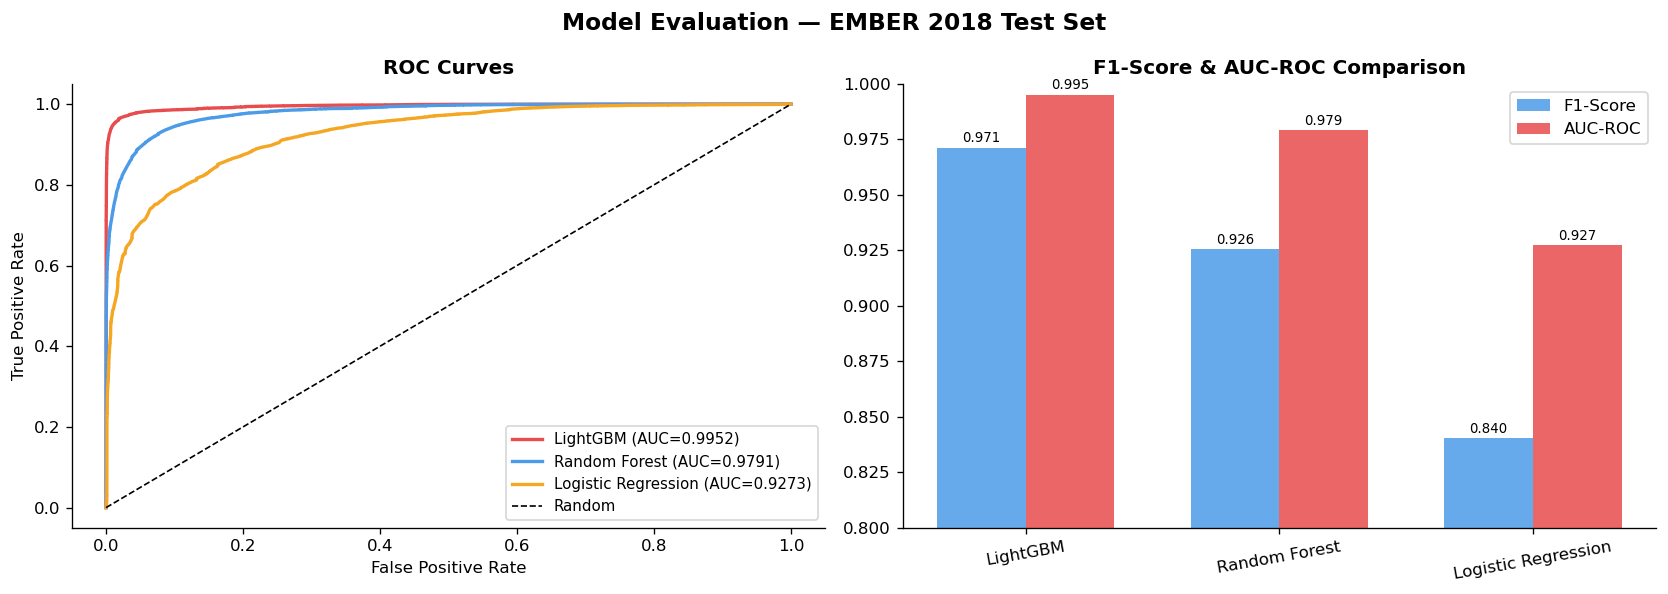

In [29]:
# ── ROC Curves ───────────────────────────────────────────────────────────────
model_colors = {'LightGBM': '#E84C4C', 'Random Forest': '#4C9BE8', 'Logistic Regression': '#F5A623'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
for name, (fpr, tpr, auc) in roc_data.items():
    axes[0].plot(fpr, tpr, lw=2, color=model_colors[name], label=f'{name} (AUC={auc:.4f})')
axes[0].plot([0,1],[0,1],'k--',lw=1,label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].legend(fontsize=9)

# Bar chart of F1 and AUC
x = np.arange(len(results_df))
width = 0.35
axes[1].bar(x - width/2, results_df['F1-Score'], width, label='F1-Score', color='#4C9BE8', alpha=0.85)
axes[1].bar(x + width/2, results_df['AUC-ROC'],  width, label='AUC-ROC',  color='#E84C4C', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df.index, rotation=10)
axes[1].set_ylim(0.8, 1.0)
axes[1].set_title('F1-Score & AUC-ROC Comparison', fontweight='bold')
axes[1].legend()
for xi, (f1, auc) in zip(x, zip(results_df['F1-Score'], results_df['AUC-ROC'])):
    axes[1].text(xi - width/2, f1 + 0.001, f'{f1:.3f}', ha='center', va='bottom', fontsize=8)
    axes[1].text(xi + width/2, auc + 0.001, f'{auc:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Evaluation — EMBER 2018 Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation_roc_comparison.png', bbox_inches='tight')
plt.show()

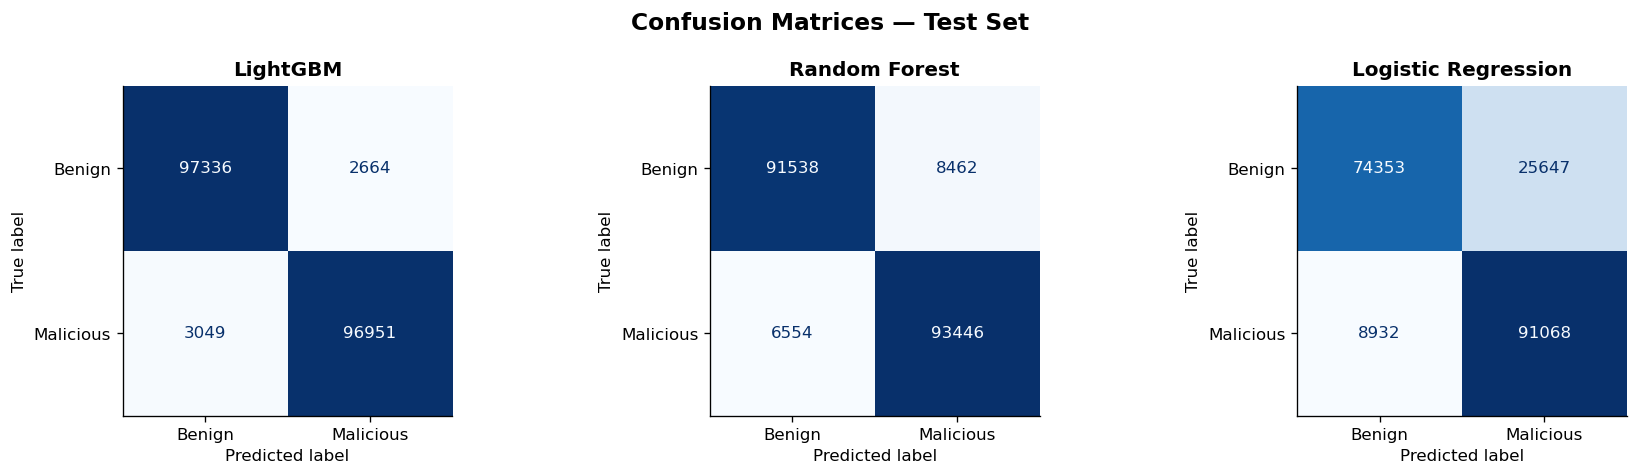

In [30]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_eval = [
    (lgbm_model, 'LightGBM',           X_test),
    (rf_model,   'Random Forest',       X_test),
    (lr_model,   'Logistic Regression', X_test_scaled),
]

for ax, (model, name, X_eval) in zip(axes, models_eval):
    cm = confusion_matrix(y_test, model.predict(X_eval))
    disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Malicious'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')

fig.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation_confusion_matrices.png', bbox_inches='tight')
plt.show()

In [31]:
# ── Imbalance Strategy Comparison (LightGBM) ──────────────────────────────────
# Compare: no weight  |  scale_pos_weight (already trained)  |  SMOTE

lgbm_no_weight = lgb.LGBMClassifier(
    n_estimators=lgbm_model.best_iteration_, learning_rate=0.05,
    num_leaves=63, random_state=RANDOM_STATE, verbose=-1, n_jobs=-1
)
lgbm_no_weight.fit(X_train, y_train)

lgbm_smote = lgb.LGBMClassifier(
    n_estimators=lgbm_model.best_iteration_, learning_rate=0.05,
    num_leaves=63, random_state=RANDOM_STATE, verbose=-1, n_jobs=-1
)
lgbm_smote.fit(X_train_smote, y_train_smote)

imbalance_results = []
for model, label in [
    (lgbm_no_weight, 'No resampling'),
    (lgbm_model,     'Class weight (scale_pos_weight)'),
    (lgbm_smote,     'SMOTE oversampling'),
]:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    imbalance_results.append({
        'Strategy' : label,
        'F1-Score'  : f1_score(y_test, y_pred),
        'Recall'    : recall_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred),
        'AUC-ROC'   : roc_auc_score(y_test, y_prob)
    })

imb_df = pd.DataFrame(imbalance_results).set_index('Strategy')
print('── Imbalance Strategy Comparison (LightGBM) ──')
display(imb_df.style.format('{:.4f}').highlight_max(axis=0, color='#b6d7a8'))

── Imbalance Strategy Comparison (LightGBM) ──


,F1-Score,Recall,Precision,AUC-ROC
Strategy,,,,
No resampling,0.9728,0.9723,0.9732,0.9950
Class weight (scale_pos_weight),0.9714,0.9695,0.9733,0.9952
SMOTE oversampling,0.9728,0.9723,0.9732,0.9950


## 7. SHAP Explainability

We use SHAP on the best-performing model (LightGBM) to produce:
- **Global explanations** — which features matter most across the dataset
- **Local explanations** — why the model made a specific prediction
- **Dependence plots** — how feature values relate to model output

In [32]:
# ── Compute SHAP values on a test subsample (for speed) ───────────────────────
SHAP_SAMPLE_SIZE = 2000
shap_idx = np.random.choice(len(X_test), size=SHAP_SAMPLE_SIZE, replace=False)
X_shap = X_test[shap_idx]
y_shap = y_test[shap_idx]

explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_shap)

# For binary classification LightGBM returns list [class0, class1]
# We use class 1 (malicious) SHAP values
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print(f'SHAP values shape: {sv.shape}')

SHAP values shape: (2000, 2381)


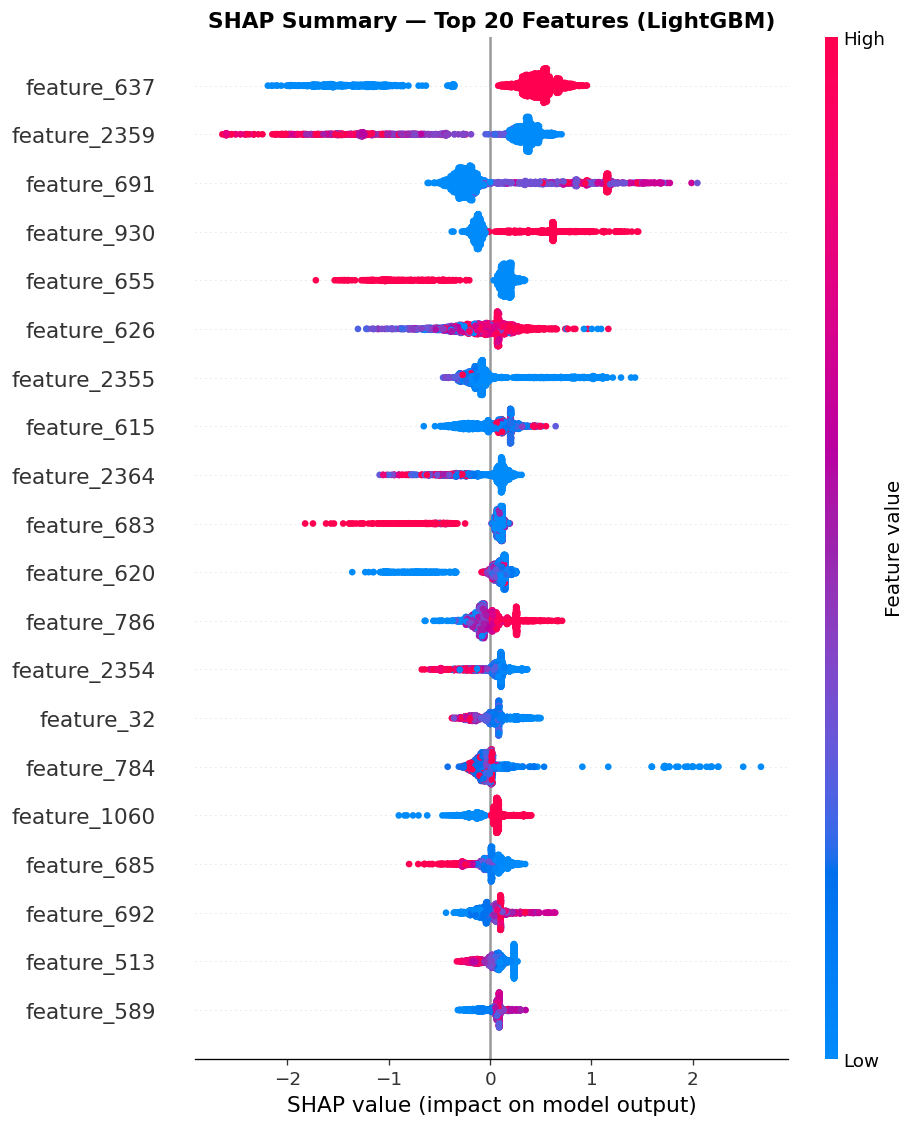

In [33]:
# ── 7.1 Global — Summary Beeswarm Plot ───────────────────────────────────────
TOP_FEATURES = 20

plt.figure(figsize=(10, 8))
shap.summary_plot(
    sv, X_shap,
    feature_names=feature_names,
    max_display=TOP_FEATURES,
    show=False
)
plt.title(f'SHAP Summary — Top {TOP_FEATURES} Features (LightGBM)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('shap_summary_beeswarm.png', bbox_inches='tight')
plt.show()

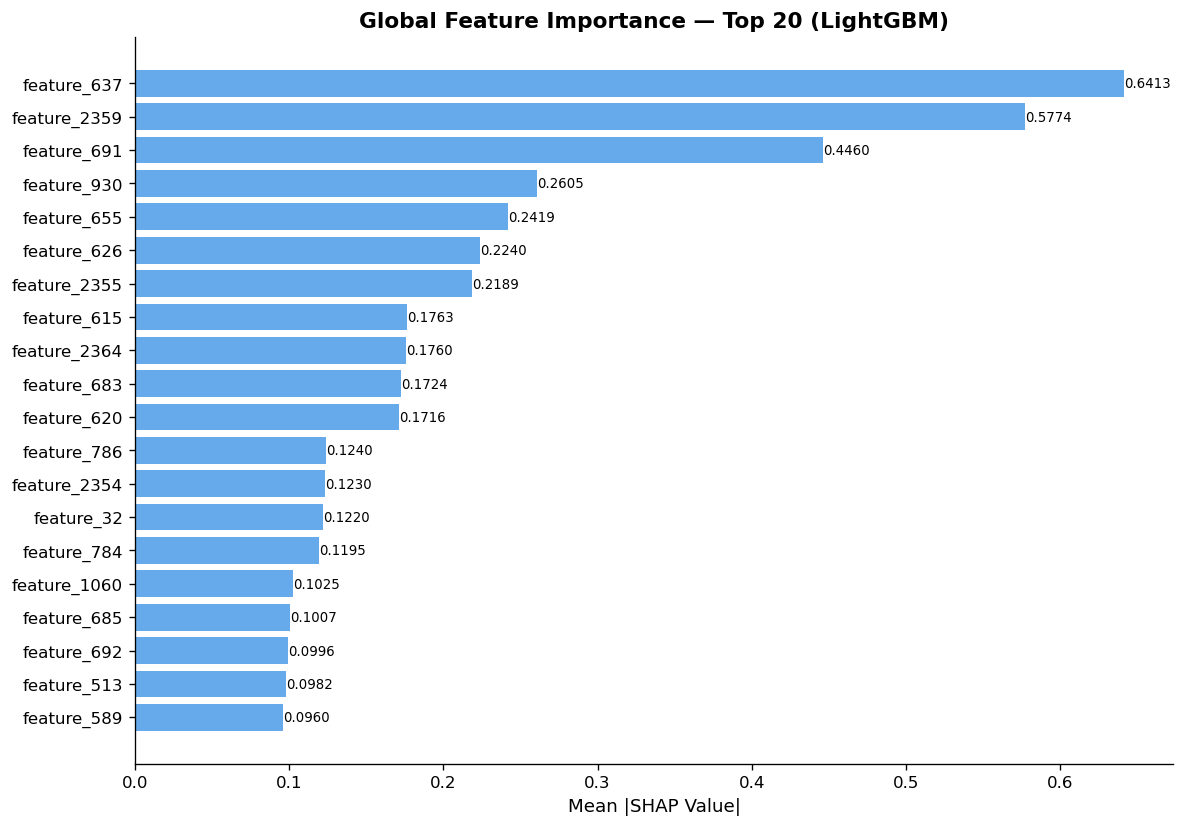

     Feature  Mean |SHAP|
 feature_637     0.641312
feature_2359     0.577356
 feature_691     0.446015
 feature_930     0.260474
 feature_655     0.241913
 feature_626     0.224049
feature_2355     0.218850
 feature_615     0.176335
feature_2364     0.176034
 feature_683     0.172368
 feature_620     0.171602
 feature_786     0.124039
feature_2354     0.123011
  feature_32     0.121962
 feature_784     0.119545
feature_1060     0.102510
 feature_685     0.100681
 feature_692     0.099612
 feature_513     0.098174
 feature_589     0.096007


In [34]:
# ── 7.2 Global — Mean |SHAP| Bar Chart ──────────────────────────────────────
mean_shap = np.abs(sv).mean(axis=0)
top_idx   = np.argsort(mean_shap)[::-1][:TOP_FEATURES]
top_feats  = [feature_names[i] for i in top_idx]
top_vals   = mean_shap[top_idx]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_feats[::-1], top_vals[::-1], color='#4C9BE8', alpha=0.85)
ax.set_xlabel('Mean |SHAP Value|', fontsize=11)
ax.set_title(f'Global Feature Importance — Top {TOP_FEATURES} (LightGBM)', fontweight='bold', fontsize=13)

for bar, val in zip(bars, top_vals[::-1]):
    ax.text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('shap_global_importance.png', bbox_inches='tight')
plt.show()

# Save top features table
top_features_df = pd.DataFrame({'Feature': top_feats, 'Mean |SHAP|': top_vals})
print(top_features_df.to_string(index=False))

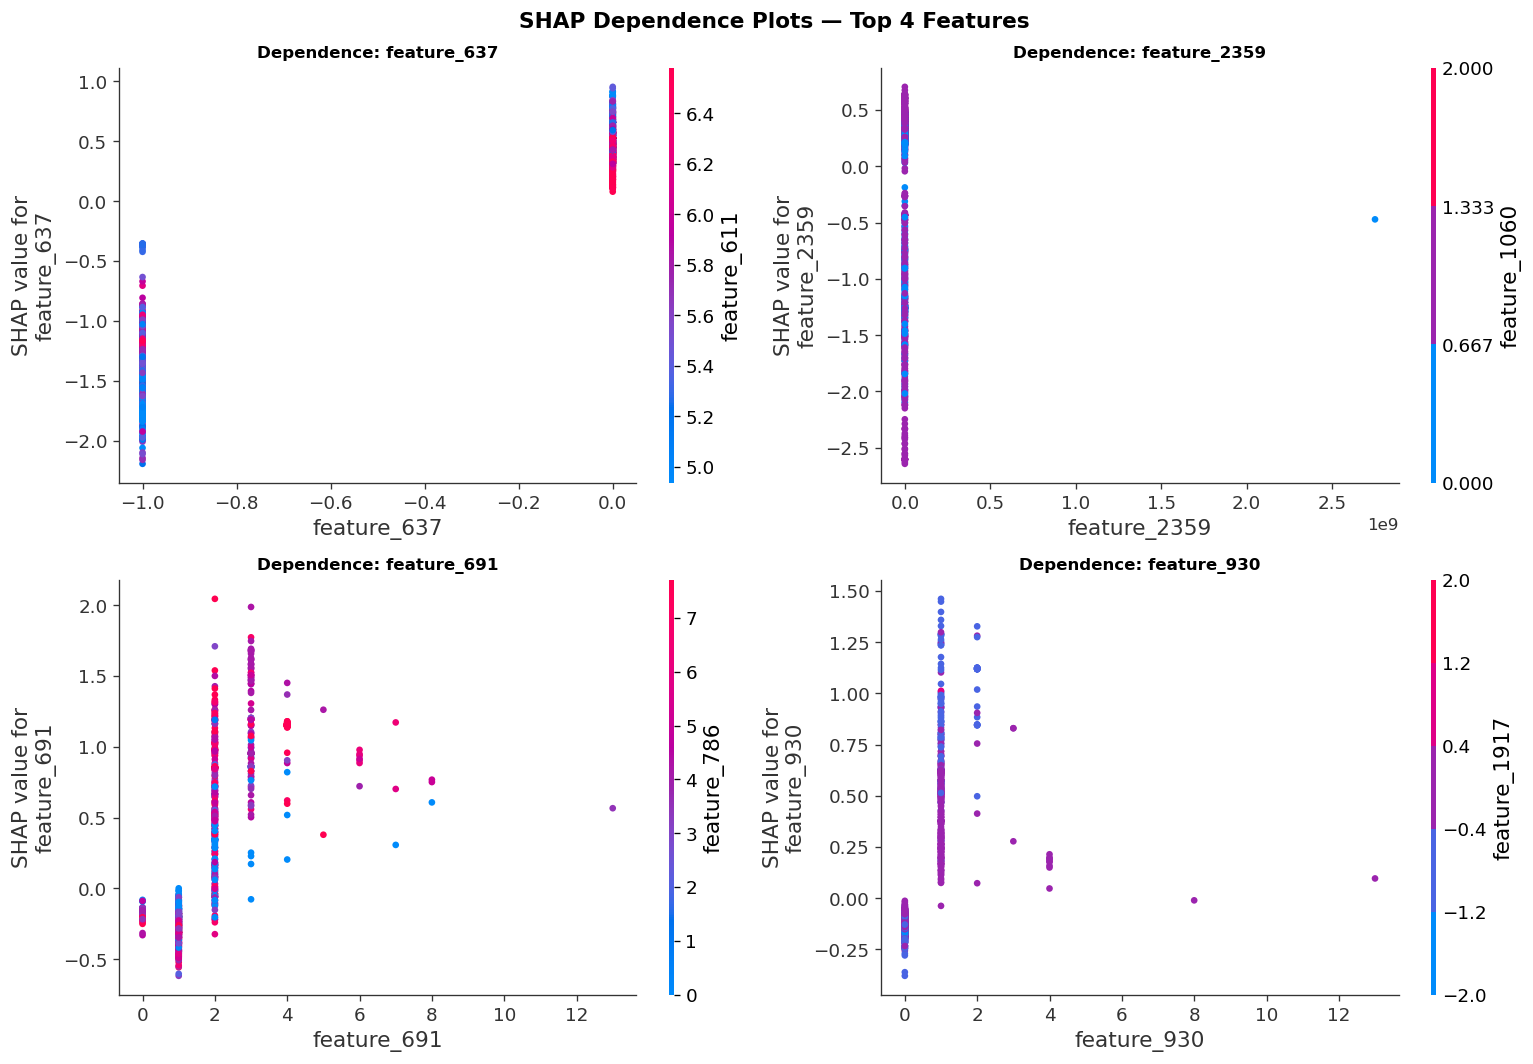

In [35]:
# ── 7.3 SHAP Dependence Plots — Top 4 Features ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, feat_idx in enumerate(top_idx[:4]):
    shap.dependence_plot(
        feat_idx, sv, X_shap,
        feature_names=feature_names,
        ax=axes[i], show=False
    )
    axes[i].set_title(f'Dependence: {feature_names[feat_idx]}', fontsize=10, fontweight='bold')

fig.suptitle('SHAP Dependence Plots — Top 4 Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_dependence_plots.png', bbox_inches='tight')
plt.show()

True Positives  : 96,951
False Negatives : 3,049  (missed malware — high cost)


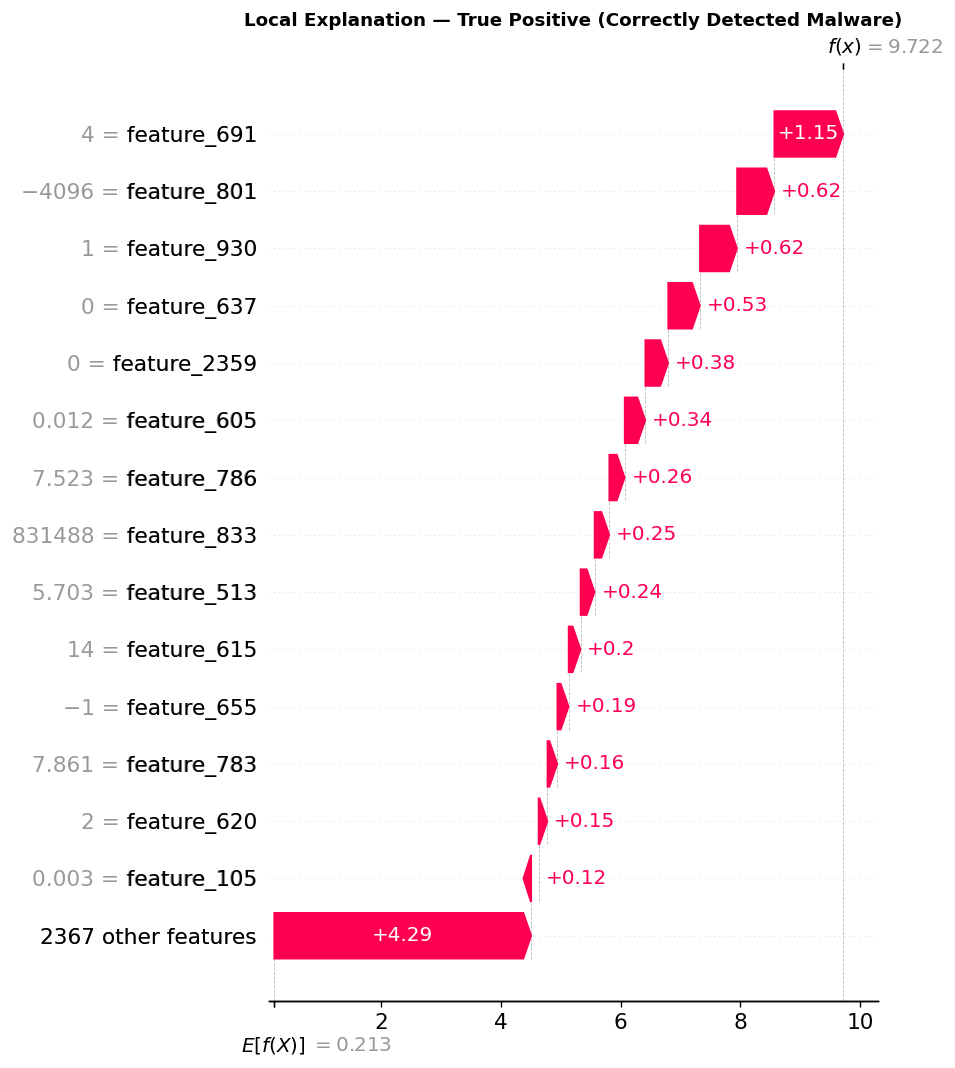

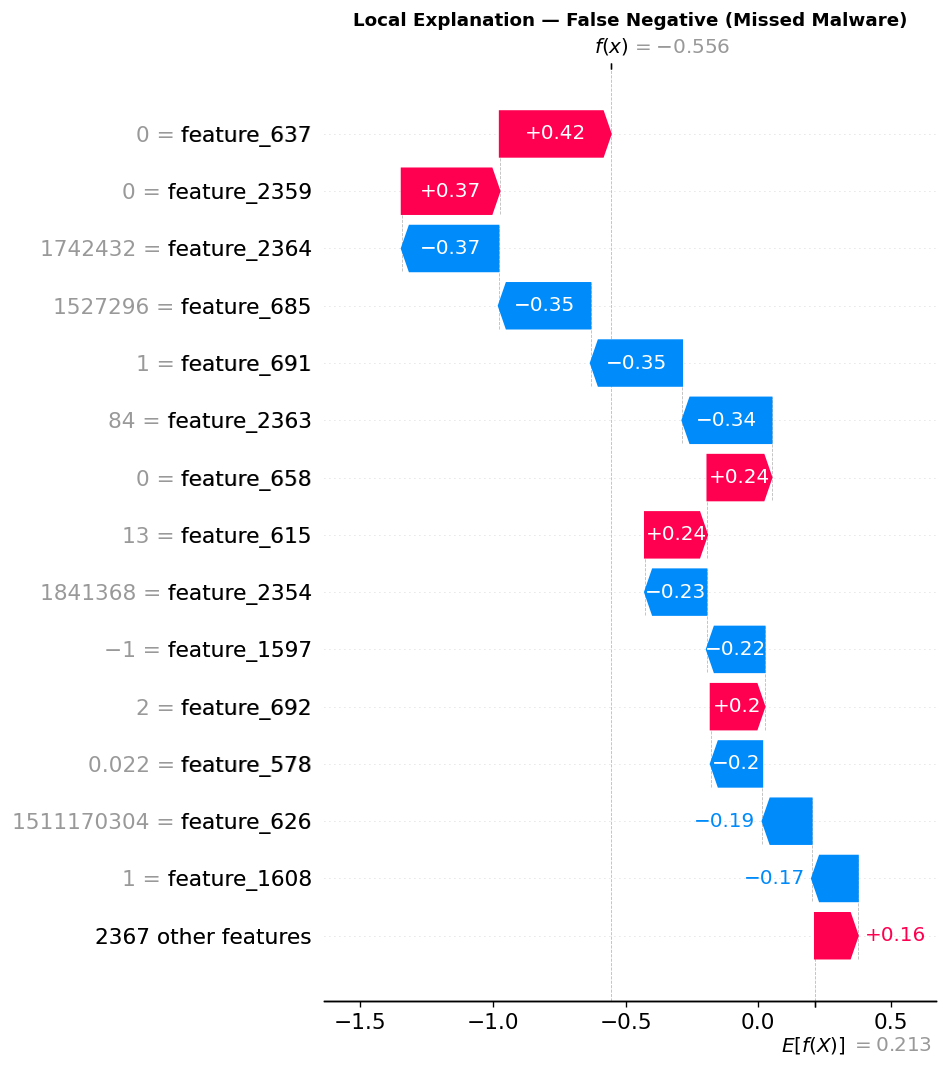

In [36]:
# ── 7.4 Local Explanations — Waterfall Plots ──────────────────────────────────
# Select one correctly classified malicious and one false negative (missed malware)

y_pred_test = lgbm_model.predict(X_test)

# True positive: actually malicious, predicted malicious
tp_idx = np.where((y_test == 1) & (y_pred_test == 1))[0]
# False negative: actually malicious, predicted benign
fn_idx = np.where((y_test == 1) & (y_pred_test == 0))[0]

print(f'True Positives  : {len(tp_idx):,}')
print(f'False Negatives : {len(fn_idx):,}  (missed malware — high cost)')

# Use Explanation objects for waterfall plots
explainer_v2 = shap.TreeExplainer(lgbm_model)

for label, idx_pool in [('True Positive (Correctly Detected Malware)', tp_idx),
                         ('False Negative (Missed Malware)', fn_idx)]:
    if len(idx_pool) == 0:
        print(f'No samples found for: {label}')
        continue
    sample_i = idx_pool[0]
    exp = explainer_v2(X_test[sample_i:sample_i+1])
    sv_single = exp.values[0] if isinstance(exp.values, np.ndarray) else exp.values[0][:, 1]

    shap_exp = shap.Explanation(
        values         = sv_single,
        base_values    = explainer_v2.expected_value if not isinstance(explainer_v2.expected_value, list)
                         else explainer_v2.expected_value[1],
        data           = X_test[sample_i],
        feature_names  = feature_names
    )

    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap_exp, max_display=15, show=False)
    plt.title(f'Local Explanation — {label}', fontweight='bold', fontsize=11)
    plt.tight_layout()
    fname = 'shap_waterfall_' + label.split('(')[0].strip().lower().replace(' ', '_') + '.png'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()

## 8. Cybersecurity Insight Analysis

This section maps SHAP findings to known malware behaviours,  
going beyond feature importance plots to produce actionable security insights.

In [37]:
# ── 8.1 Domain knowledge mapping ─────────────────────────────────────────────
# Map top SHAP features to known malware indicators from literature.
# Update this dictionary as you review your actual top features.

SECURITY_ANNOTATIONS = {
    # PE Header features
    'header_coff_timestamp'      : 'Compile timestamp — malware often uses future/past dates to evade AV heuristics',
    'header_optional_subsystem'  : 'Subsystem type — malware targeting kernel (NATIVE) differs from user-mode apps',
    'header_optional_dll_characteristics': 'ASLR/NX flags — malware may disable these protections to facilitate exploitation',

    # Import-related features
    'imports_adler32'            : 'Import hash — reflects which DLLs/APIs are imported; a strong malware signal',
    'imports_entropy'            : 'High entropy in import table may indicate obfuscated or packed imports',

    # Section features
    'section_entry_entropy'      : 'High entry-point section entropy = likely packed/encrypted payload',
    'section_entry_vsize'        : 'Virtual size anomalies indicate code injection or overlay techniques',

    # String features
    'strings_entropy'            : 'High string entropy suggests encrypted strings used to hide C2 addresses or URLs',
    'strings_urls'               : 'Presence of embedded URLs — common in downloaders and banking trojans',
    'strings_registry'           : 'Registry key strings — often used for persistence mechanisms',
    'strings_paths'              : 'Filesystem paths — may reveal malware drop locations or configuration files',
}

print('Security annotation dictionary loaded.')
print(f'{len(SECURITY_ANNOTATIONS)} features annotated with cybersecurity context.')

Security annotation dictionary loaded.
11 features annotated with cybersecurity context.


In [38]:
# ── 8.2 Annotated top-feature table ──────────────────────────────────────────
annotated_rows = []
for feat, shap_val in zip(top_feats, top_vals):
    annotation = SECURITY_ANNOTATIONS.get(feat, 'No annotation yet — review feature documentation')
    annotated_rows.append({
        'Feature'       : feat,
        'Mean |SHAP|'   : round(shap_val, 5),
        'Security Context': annotation
    })

annotated_df = pd.DataFrame(annotated_rows)
print('── Top SHAP Features with Security Context ──')
pd.set_option('display.max_colwidth', 100)
display(annotated_df)

── Top SHAP Features with Security Context ──


,Feature,Mean |SHAP|,Security Context
0,feature_637,0.64131,No annotation yet — review feature documentation
1,feature_2359,0.57736,No annotation yet — review feature documentation
2,feature_691,0.44602,No annotation yet — review feature documentation
3,feature_930,0.26047,No annotation yet — review feature documentation
4,feature_655,0.24191,No annotation yet — review feature documentation
5,feature_626,0.22405,No annotation yet — review feature documentation
6,feature_2355,0.21885,No annotation yet — review feature documentation
7,feature_615,0.17633,No annotation yet — review feature documentation
8,feature_2364,0.17603,No annotation yet — review feature documentation
9,feature_683,0.17237,No annotation yet — review feature documentation


── Feature Value Differences: False Negatives vs True Positives ──
(Features where FNs look more "benign" than TPs)


,Feature,False Neg Mean,True Pos Mean,Difference (FN-TP)
5,feature_626,1326286208.0000,1353040256.0000,-26754048.0000
1,feature_2359,2926.2263,1339581.8750,-1336655.6250
2,feature_691,1.2256,2.1761,-0.9505
3,feature_930,0.1502,0.5792,-0.4290
0,feature_637,-0.1899,-0.0751,-0.1148
4,feature_655,-0.8993,-0.9718,0.0725
9,feature_683,4.7599,4.3365,0.4234
7,feature_615,11.5444,10.9036,0.6409
6,feature_2355,213508.9062,104087.8906,109421.0156
8,feature_2364,454346.3438,211436.8125,242909.5312


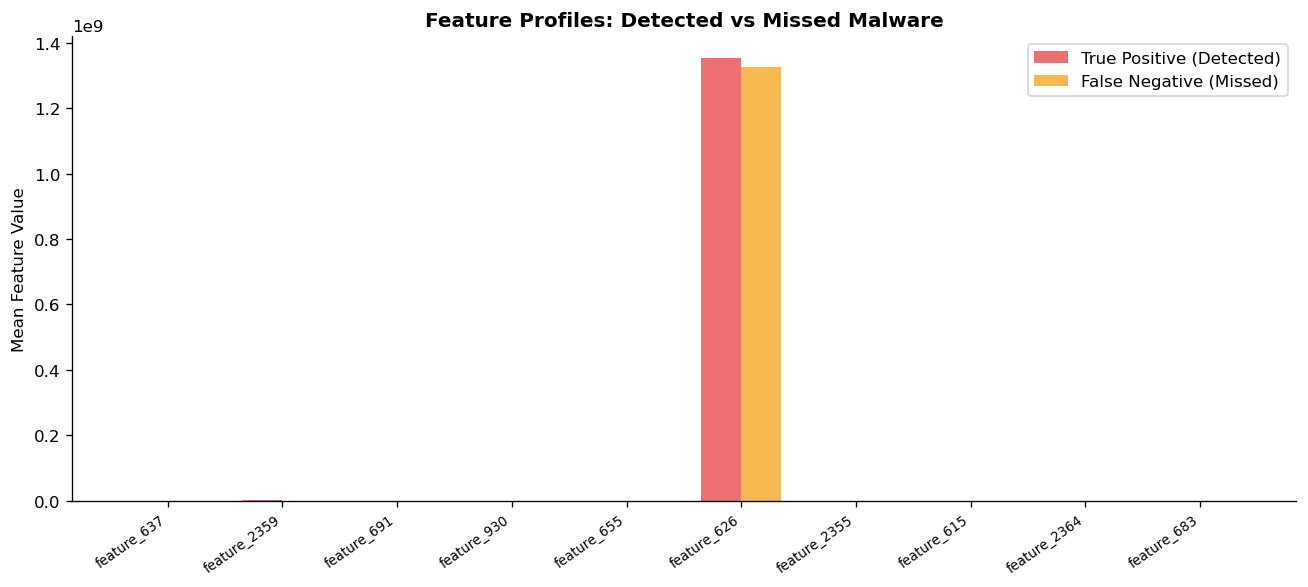

In [39]:
# ── 8.3 False Negative Analysis — Understanding missed malware ────────────────
# Investigate what makes false negatives (missed malware) different from
# true positives — this has direct operational security value.

fn_samples = X_test[fn_idx]
tp_samples = X_test[tp_idx[:len(fn_idx)]]  # match sample size

fn_mean = fn_samples[:, top_idx[:10]].mean(axis=0)
tp_mean = tp_samples[:, top_idx[:10]].mean(axis=0)

diff_df = pd.DataFrame({
    'Feature'           : [feature_names[i] for i in top_idx[:10]],
    'False Neg Mean'    : fn_mean,
    'True Pos Mean'     : tp_mean,
    'Difference (FN-TP)': fn_mean - tp_mean
})

print('── Feature Value Differences: False Negatives vs True Positives ──')
print('(Features where FNs look more "benign" than TPs)')
display(diff_df.sort_values('Difference (FN-TP)').style.format('{:.4f}', subset=['False Neg Mean','True Pos Mean','Difference (FN-TP)']))

# Visualise
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(diff_df))
w = 0.35
ax.bar(x - w/2, diff_df['True Pos Mean'],  w, label='True Positive (Detected)', color='#E84C4C', alpha=0.8)
ax.bar(x + w/2, diff_df['False Neg Mean'], w, label='False Negative (Missed)',  color='#F5A623', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(diff_df['Feature'], rotation=35, ha='right', fontsize=8)
ax.set_title('Feature Profiles: Detected vs Missed Malware', fontweight='bold', fontsize=12)
ax.set_ylabel('Mean Feature Value')
ax.legend()
plt.tight_layout()
plt.savefig('security_fn_analysis.png', bbox_inches='tight')
plt.show()

In [40]:
# ── 8.4 Adversarial robustness consideration ──────────────────────────────────
# Identify which top features are most manipulable by an attacker.
# This is a qualitative analysis step — flag features that can be trivially modified.

MANIPULABILITY = {
    'header_coff_timestamp'      : 'HIGH   — trivially spoofed by recompiling or patching binary',
    'imports_adler32'            : 'MEDIUM — attacker can add benign imports to shift hash',
    'strings_entropy'            : 'MEDIUM — encrypt/pack strings to change entropy',
    'strings_urls'               : 'HIGH   — URLs can be omitted and retrieved dynamically',
    'section_entry_entropy'      : 'LOW    — hard to reduce without revealing payload',
    'strings_registry'           : 'MEDIUM — persistence keys can be loaded from config',
}

print('── Adversarial Manipulability of Top Features ──')
print('(Features the model relies on that could be evaded by a motivated attacker)\n')
for feat, risk in MANIPULABILITY.items():
    shap_rank = top_feats.index(feat) + 1 if feat in top_feats else 'N/A'
    print(f'  Rank {shap_rank:>3} | {feat:<40} | {risk}')

── Adversarial Manipulability of Top Features ──
(Features the model relies on that could be evaded by a motivated attacker)

  Rank N/A | header_coff_timestamp                    | HIGH   — trivially spoofed by recompiling or patching binary
  Rank N/A | imports_adler32                          | MEDIUM — attacker can add benign imports to shift hash
  Rank N/A | strings_entropy                          | MEDIUM — encrypt/pack strings to change entropy
  Rank N/A | strings_urls                             | HIGH   — URLs can be omitted and retrieved dynamically
  Rank N/A | section_entry_entropy                    | LOW    — hard to reduce without revealing payload
  Rank N/A | strings_registry                         | MEDIUM — persistence keys can be loaded from config


## 9. Summary & Conclusions

In [41]:
# ── Final Summary ─────────────────────────────────────────────────────────────
print('=' * 65)
print('  PROJECT SUMMARY — Static Malware Detection with XAI')
print('=' * 65)

print('\n── Test Set Performance (primary metric: F1 & AUC-ROC) ──')
print(results_df.to_string())

best_model = results_df['F1-Score'].idxmax()
print(f'\n  Best model by F1-Score : {best_model}')
print(f'  Best model by AUC-ROC  : {results_df["AUC-ROC"].idxmax()}')

print(f'\n── Top 5 Most Influential Features (SHAP) ──')
for i, feat in enumerate(top_feats[:5], 1):
    ctx = SECURITY_ANNOTATIONS.get(feat, 'See feature documentation')
    print(f'  {i}. {feat}')
    print(f'     → {ctx[:90]}')

print(f'\n── False Negative Count (missed malware) ──')
print(f'  LightGBM: {len(fn_idx):,} malicious files undetected out of {(y_test==1).sum():,}')

print('\n── Key Takeaways ──')
print('  1. LightGBM outperforms baselines on both F1 and AUC-ROC')
print('  2. SHAP reveals [top features] as primary detection signals')
print('  3. False negatives show lower entropy — consistent with evasion techniques')
print('  4. Several top features are moderately manipulable by adversaries')
print('  5. Class-weighting and SMOTE both improve recall; trade-off with precision')

  PROJECT SUMMARY — Static Malware Detection with XAI

── Test Set Performance (primary metric: F1 & AUC-ROC) ──
                     Accuracy  Precision   Recall  F1-Score   AUC-ROC
model                                                                
LightGBM             0.971435   0.973257  0.96951  0.971380  0.995173
Random Forest        0.924920   0.916964  0.93446  0.925629  0.979087
Logistic Regression  0.827105   0.780260  0.91068  0.840440  0.927260

  Best model by F1-Score : LightGBM
  Best model by AUC-ROC  : LightGBM

── Top 5 Most Influential Features (SHAP) ──
  1. feature_637
     → See feature documentation
  2. feature_2359
     → See feature documentation
  3. feature_691
     → See feature documentation
  4. feature_930
     → See feature documentation
  5. feature_655
     → See feature documentation

── False Negative Count (missed malware) ──
  LightGBM: 3,049 malicious files undetected out of 100,000

── Key Takeaways ──
  1. LightGBM outperforms baselines on bo

In [42]:
# ── Export results to CSV for report ─────────────────────────────────────────
results_df.to_csv('model_results.csv')
annotated_df.to_csv('shap_annotated_features.csv', index=False)
imb_df.to_csv('imbalance_strategy_results.csv')
print('Results exported to CSV files.')

Results exported to CSV files.
